## Практика

### Загрузка необходимых файлов и библиотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv('../../data/dataset_2_1.csv',  index_col=0)
df.head()

,Регион,Год,Объем_сточных_вод_млн_м3,Инвестиции_норм_%,ВРП_на_душу_руб,Индексы_производства_продукции_СХ_%,Доля_городского_населения_%,Использование_свеж_воды_млн_м3,Индекс_промыш_производства_%,Числ_насел
0,Алтайский край,2000,31.0,0.377989,17660.5,122.0,52.8,569.0,109.2,2641.1
1,Алтайский край,2001,34.0,0.180408,23509.0,104.5,53.1,599.0,109.4,2621.1
2,Алтайский край,2002,36.0,0.092283,27991.2,103.1,53.2,563.0,100.1,2602.6
3,Алтайский край,2003,36.0,0.056477,34295.8,100.8,53.5,516.0,105.5,2572.0
4,Алтайский край,2004,36.0,0.033324,44934.9,99.5,53.7,488.0,102.6,2539.4


In [4]:
df1 = pd.read_csv('../../data/dataset_2_0.csv',  index_col=0)
df1.head()

,Регион,Год,Объем_сточных_вод_млн_м3,Инвестиции_в_ООС_тыс_руб,ВРП_млн_руб,ВРП_на_душу_руб,Индексы_производства_продукции_СХ_%,Доля_городского_населения_%,Использование_свеж_воды_млн_м3,Индекс_промыш_производства_%
0,Белгородская область,2000,45.0,116202.6,42074.5,27969.5,120.3,65.2,354.0,109.10
1,Брянская область,2000,100.0,54949.8,24650.5,17413.5,109.3,68.6,150.0,117.30
2,Владимирская область,2000,182.0,24719.4,33017.7,21073.3,108.0,79.8,222.0,119.47
3,Воронежская область,2000,190.0,127056.8,49523.9,20365.1,129.0,61.6,695.0,105.40
4,Ивановская область,2000,168.0,62264.0,16900.0,14240.0,115.0,82.5,264.0,110.30


### **Описание колонок:**

1. **Регион** — название субъекта РФ или другого территориального образования.
2. **Год** — календарный год сбора данных.
3. **Объем_сточных_вод_млн_м3** — общий объём сточных вод (отведённых после использования воды и подлежащих очистке), в миллионах м³.
4. **Инвестиции_норм_%** — показатель инвестиций в охрану окружающей среды, нормализованный по ВРП (отношение или приведённый показатель, сглаживающий различия между регионами по величине их экономики), в процентах.
5. **ВРП_на_душу_руб** — валовой региональный продукт на душу населения (экономический аналог ВВП, рассчитанный для региона), в рублях.
6. **Индексы_производства_продукции_СХ_%** — индекс производства продукции сельского хозяйства, в процентах к предыдущему году.
7. **Доля_городского_населения_%** — процентное соотношение городского населения в регионе.
8. **Использование_свеж_воды_млн_м3** — объём использования свежей воды, в миллионах м³.
9. **Индекс_промыш_производства_%** — индекс промышленного производства в регионе, в процентах к предыдущему году.

**Инвестиции_норм_%** — целевая переменная исследования: нормализованный показатель инвестиций в охрану окружающей среды для анализа взаимосвязи с экологическими и экономическими факторами.

In [5]:
df["инвестиции_к_ВРП"] = df["Инвестиции_норм_%"]  # у тебя уже нормировано на ВРП
df["сбросы_на_человека"] = df["Объем_сточных_вод_млн_м3"] / df1["ВРП_млн_руб"]


features = [
    "инвестиции_к_ВРП",
    "Доля_городского_населения_%",
    "Индекс_промыш_производства_%",
    "Индексы_производства_продукции_СХ_%",
    "Год",
]

X = df[features]
y = df["сбросы_на_человека"]


In [6]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# 2. Убираем строки с NaN в X или y
data = pd.concat([X, y], axis=1).dropna()
X_clean = data[features]
y_clean = data["сбросы_на_человека"]

# 3. Разбиваем и обучаем
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

lin = LinearRegression()
lin.fit(X_train_sc, y_train)

y_pred = lin.predict(X_test_sc)
print("R2:", round(r2_score(y_test, y_pred), 3))
print("MAE:", round(mean_absolute_error(y_test, y_pred), 3))
print("Коэффициенты:")
for name, coef in zip(features, lin.coef_):
    print(f"{name:35s} {coef:.4f}")

R2: 0.018
MAE: 0.002
Коэффициенты:
инвестиции_к_ВРП                    0.0001
Доля_городского_населения_%         0.0005
Индекс_промыш_производства_%        0.0000
Индексы_производства_продукции_СХ_% 0.0000
Год                                 -0.0005


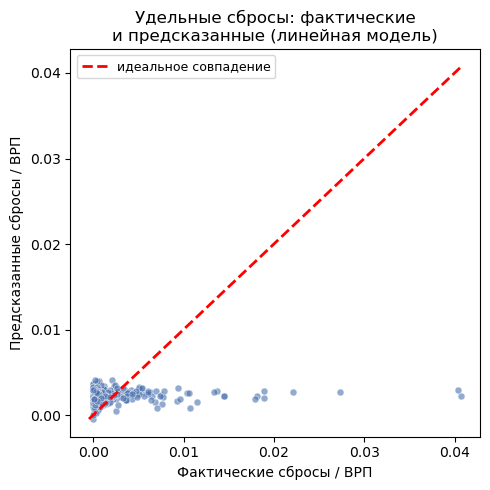

In [7]:
plt.figure(figsize=(5, 5))
plt.scatter(
    y_test,
    y_pred,
    alpha=0.6,
    s=25,
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.5
)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    linewidth=2,
    label="идеальное совпадение"
)

plt.xlabel("Фактические сбросы / ВРП")
plt.ylabel("Предсказанные сбросы / ВРП")
plt.title("Удельные сбросы: фактические\nи предсказанные (линейная модель)")
plt.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()


In [8]:
coefs = lin.coef_
coef_dict = dict(zip(features, coefs))

for k, v in coef_dict.items():
    print(k, v)


инвестиции_к_ВРП 8.591855736515693e-05
Доля_городского_населения_% 0.0005119390542784527
Индекс_промыш_производства_% 1.0095720749057744e-06
Индексы_производства_продукции_СХ_% 1.3027159278090618e-05
Год -0.0005043562570125651


In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Целевая переменная: сбросы на человека
df["сбросы_на_человека"] = df["Объем_сточных_вод_млн_м3"] / df["Числ_насел"]
df["log_населения"] = np.log(df["Числ_насел"])

features = [
    "Инвестиции_норм_%",
    "Доля_городского_населения_%",
    "Индекс_промыш_производства_%",
    "Индексы_производства_продукции_СХ_%",
    "log_населения",
    "Год",
]

X = df[features]
y = df["сбросы_на_человека"]

# 2. Убираем строки с NaN в X или y
data = pd.concat([X, y], axis=1).dropna()
X_clean = data[features]
y_clean = data["сбросы_на_человека"]

# 3. Разбиваем и обучаем
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

lin = LinearRegression()
lin.fit(X_train_sc, y_train)

y_pred = lin.predict(X_test_sc)
print("R2:", round(r2_score(y_test, y_pred), 3))
print("MAE:", round(mean_absolute_error(y_test, y_pred), 3))
print("Коэффициенты:")
for name, coef in zip(features, lin.coef_):
    print(f"{name:35s} {coef:.4f}")


R2: 0.291
MAE: 0.063
Коэффициенты:
Инвестиции_норм_%                   0.0088
Доля_городского_населения_%         0.0504
Индекс_промыш_производства_%        -0.0051
Индексы_производства_продукции_СХ_% -0.0011
log_населения                       -0.0234
Год                                 -0.0217


In [10]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# те же X_clean, y_clean, что и выше
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# 1. Линейная регрессия (уже была, но оставим для сравнения)
lin = LinearRegression()
lin.fit(X_train_sc, y_train)
y_pred_lin = lin.predict(X_test_sc)

print("LinearRegression")
print("  R2:", round(r2_score(y_test, y_pred_lin), 3))
print("  MAE:", round(mean_absolute_error(y_test, y_pred_lin), 4))

# 2. RandomForest
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)  # для деревьев масштабирование не обязательно
y_pred_rf = rf.predict(X_test)

print("\nRandomForest")
print("  R2:", round(r2_score(y_test, y_pred_rf), 3))
print("  MAE:", round(mean_absolute_error(y_test, y_pred_rf), 4))

# 3. GradientBoosting
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

print("\nGradientBoosting")
print("  R2:", round(r2_score(y_test, y_pred_gbr), 3))
print("  MAE:", round(mean_absolute_error(y_test, y_pred_gbr), 4))


LinearRegression
  R2: 0.291
  MAE: 0.0627

RandomForest
  R2: 0.875
  MAE: 0.0244

GradientBoosting
  R2: 0.767
  MAE: 0.0364


In [11]:
imp_rf = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
imp_gbr = pd.Series(gbr.feature_importances_, index=features).sort_values(ascending=False)

print("\nRandomForest: важность признаков")
print(imp_rf.round(4))

print("\nGradientBoosting: важность признаков")
print(imp_gbr.round(4))



RandomForest: важность признаков
log_населения                          0.4831
Доля_городского_населения_%            0.3401
Год                                    0.0687
Инвестиции_норм_%                      0.0590
Индекс_промыш_производства_%           0.0253
Индексы_производства_продукции_СХ_%    0.0238
dtype: float64

GradientBoosting: важность признаков
log_населения                          0.4921
Доля_городского_населения_%            0.3904
Год                                    0.0481
Инвестиции_норм_%                      0.0461
Индекс_промыш_производства_%           0.0122
Индексы_производства_продукции_СХ_%    0.0112
dtype: float64


In [12]:
df

,Регион,Год,Объем_сточных_вод_млн_м3,Инвестиции_норм_%,ВРП_на_душу_руб,Индексы_производства_продукции_СХ_%,Доля_городского_населения_%,Использование_свеж_воды_млн_м3,Индекс_промыш_производства_%,Числ_насел,инвестиции_к_ВРП,сбросы_на_человека,log_населения
0,Алтайский край,2000,31.00,0.377989,17660.5,122.000,52.8,569.00,109.2,2641.1,0.377989,0.011738,7.878951
1,Алтайский край,2001,34.00,0.180408,23509.0,104.500,53.1,599.00,109.4,2621.1,0.180408,0.012972,7.871349
2,Алтайский край,2002,36.00,0.092283,27991.2,103.100,53.2,563.00,100.1,2602.6,0.092283,0.013832,7.864266
3,Алтайский край,2003,36.00,0.056477,34295.8,100.800,53.5,516.00,105.5,2572.0,0.056477,0.013997,7.852439
4,Алтайский край,2004,36.00,0.033324,44934.9,99.500,53.7,488.00,102.6,2539.4,0.033324,0.014177,7.839683
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1963,г. Санкт-Петербург,2019,920.33,0.250755,932159.6,101.875,100.0,806.26,104.5,5383.9,0.250755,0.170941,8.591168
1964,г. Санкт-Петербург,2020,914.37,0.352492,954862.8,100.900,100.0,759.13,98.4,5398.1,0.352492,0.169387,8.593802
1965,г. Санкт-Петербург,2021,945.06,0.227571,1682758.7,101.100,100.0,790.51,106.4,5384.3,0.227571,0.175521,8.591243
1966,г. Санкт-Петербург,2022,932.70,0.102214,1992591.6,103.400,100.0,782.23,106.1,5600.0,0.102214,0.166554,8.630522


### EDA

In [19]:
# Смотрим размер датасета
df.shape

(1968, 10)

In [20]:
df.describe()

,Год,Объем_сточных_вод_млн_м3,Инвестиции_норм_%,ВРП_на_душу_руб,Индексы_производства_продукции_СХ_%,Доля_городского_населения_%,Использование_свеж_воды_млн_м3,Индекс_промыш_производства_%,Числ_насел
count,1968.000000,1968.000000,1884.000000,1.968000e+03,1968.000000,1968.000000,1968.000000,1968.000000,1968.000000
mean,2011.500000,189.902536,0.782505,4.168486e+05,102.258816,70.151067,691.476479,105.083659,1746.569766
std,6.923946,266.510499,1.143861,8.511817e+05,10.717656,12.567786,941.456301,10.074794,1737.560884
min,2000.000000,0.000000,0.000430,6.667900e+03,41.400000,26.000000,4.720000,43.200000,40.900000
25%,2005.750000,39.715000,0.188782,9.070555e+04,97.200000,63.675000,133.490000,100.700000,711.925000
50%,2011.500000,88.805000,0.445978,2.234065e+05,101.600000,70.650000,294.000000,104.400000,1176.500000
75%,2017.250000,216.805000,0.940569,4.353094e+05,106.300000,77.800000,799.000000,109.000000,2453.600000
max,2023.000000,2661.000000,13.429565,1.199540e+07,185.000000,100.000000,6849.000000,273.700000,13104.200000


Интерпретация

1. Структура и масштаб данных

Всего 1968 наблюдений по 82 субъектам Российской Федерации. Временной охват: с 2000по 2023 года включительно.
Объём сточных вод (млн м³/год) находится в диапазоне от 0 до 2661, медианное значение — 88.8, среднее — 189.9.

Инвестиции в охрану окружающей среды (нормированные, %) варьируются от 0.00043 до 13.43, медиана по региону — 0.45%, среднее — 0.78%, стандартное отклонение — 1.14.

ВРП на душу лежит в диапазоне от 6.7 тыс. до 12 млн рублей, что отражает наличие как малодоходных, так и высокодоходных территорий.

2. Экономико-демографические профили

По численности населения регионы существенно различаются: от 40.9 тыс. до 13.1 млн (медиана — 1176.5 тыс.).

Доля городского населения варьирует в пределах 26–100% (медиана — 70.65), что маркирует присутствие как урбанизированных территорий, так и преимущественно сельских субъектов.

Индекс промышленного производства в среднем 105.1%, разброс от 43.2 до 273.7 отражает различия в структуре и динамике производственного комплекса.

3. Гидрологический и производственный фон
   
Использование свежей воды — от 4.72 до 6849 млн м³, медиана — 294 млн м³; разброс параметра подтверждает наличие как водоёмких, так и маловодных отраслей/регионов.

Индексы производства продукции сельского хозяйства — от 41.4 до 185, с медианой 101.6; потенциально важный сопутствующий фактор.

In [21]:
# Проверка пропусков
df.isna().sum()

Регион                                  0
Год                                     0
Объем_сточных_вод_млн_м3                0
Инвестиции_норм_%                      84
ВРП_на_душу_руб                         0
Индексы_производства_продукции_СХ_%     0
Доля_городского_населения_%             0
Использование_свеж_воды_млн_м3          0
Индекс_промыш_производства_%            0
Числ_насел                              0
dtype: int64

Так как мы хотим выполнить достоверное сравнение, то удаляем строки из датасета с пропусками

In [22]:
df = df.dropna(subset=['Инвестиции_норм_%'])

In [23]:
# Проверка пропусков
df.isna().sum()

Регион                                 0
Год                                    0
Объем_сточных_вод_млн_м3               0
Инвестиции_норм_%                      0
ВРП_на_душу_руб                        0
Индексы_производства_продукции_СХ_%    0
Доля_городского_населения_%            0
Использование_свеж_воды_млн_м3         0
Индекс_промыш_производства_%           0
Числ_насел                             0
dtype: int64

In [24]:
# Проверяем типы
df.dtypes

Регион                                  object
Год                                      int64
Объем_сточных_вод_млн_м3               float64
Инвестиции_норм_%                      float64
ВРП_на_душу_руб                        float64
Индексы_производства_продукции_СХ_%    float64
Доля_городского_населения_%            float64
Использование_свеж_воды_млн_м3         float64
Индекс_промыш_производства_%           float64
Числ_насел                             float64
dtype: object

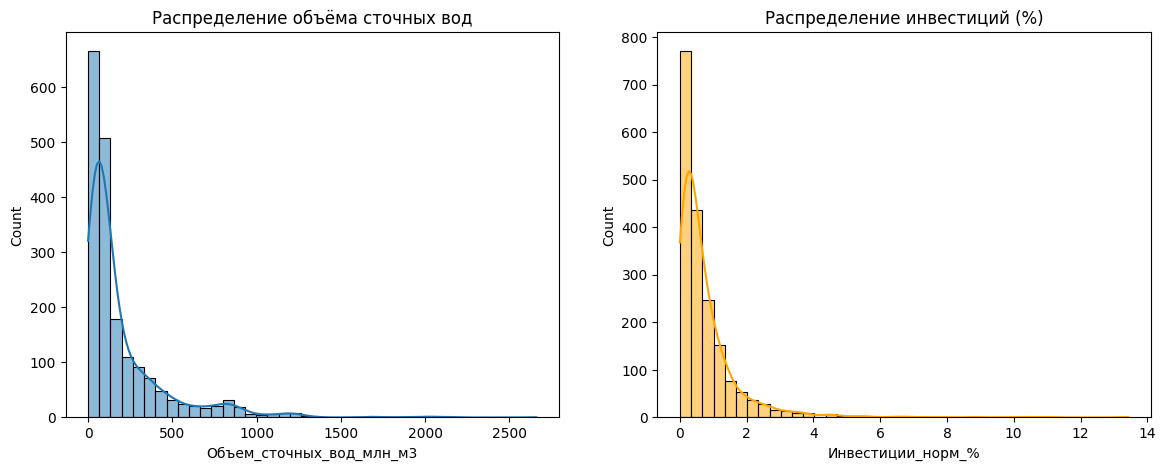

In [25]:
# 1. Гистограммы распределения
plt.figure(figsize=(14, 5))
plt.subplot(1,2,1)
sns.histplot(df['Объем_сточных_вод_млн_м3'], bins=40, kde=True)
plt.title("Распределение объёма сточных вод")
plt.subplot(1,2,2)
sns.histplot(df['Инвестиции_норм_%'], bins=40, kde=True, color='orange')
plt.title("Распределение инвестиций (%)")
plt.show()

99% регионов — низкие сбросы и инвестиции;

1% — экстремальные значения, на них всё держится.
Именно из-за них надо делать сегментированный анализ, иначе рискуем не увидеть настоящие связи между финансированием и снижением загрязнения.

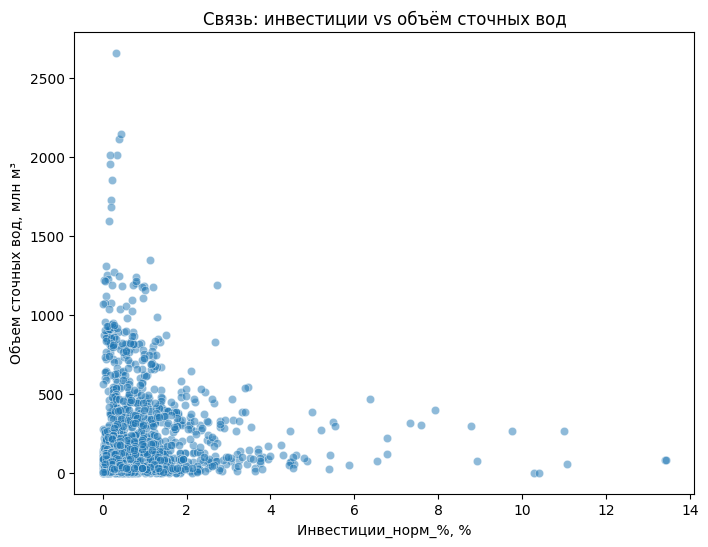

In [26]:
# 2. Scatter plot (общая взаимосвязь)
plt.figure(figsize=(8,6))
sns.scatterplot(x='Инвестиции_норм_%', y='Объем_сточных_вод_млн_м3', data=df, alpha=0.5)
plt.title("Связь: инвестиции vs объём сточных вод")
plt.xlabel("Инвестиции_норм_%, %")
plt.ylabel("Объем сточных вод, млн м³")
plt.show()

Большинство регионов мало инвестируют и сбрасывают мало сточных вод.

Самые крупные загрязнители почти не тратят на экологию.

Высокие инвестиции не гарантируют низких сбросов, но таких случаев мало.

Корреляции между переменными нет: она либо очень слабая, либо скрыта другими факторами (размером региона, структурой экономики и пр.).

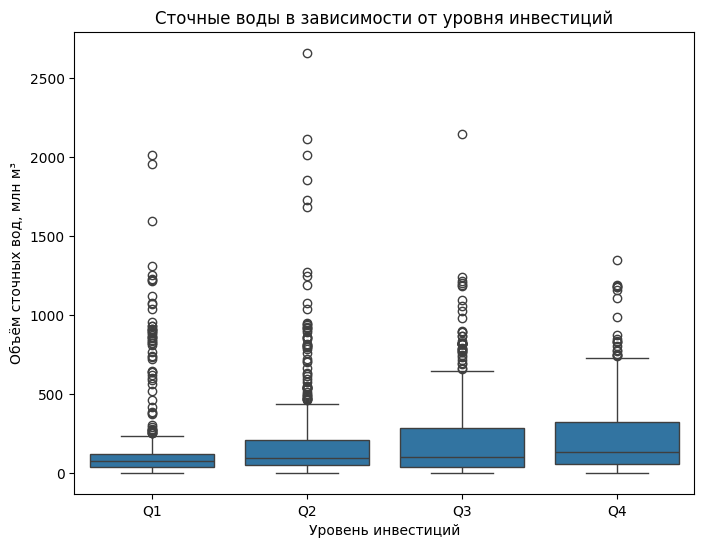

In [27]:
# 3. Boxplots по user-defined квартилям инвестиций
df['inv_quartile'] = pd.qcut(df['Инвестиции_норм_%'], 4, labels=['Q1','Q2','Q3','Q4'])
plt.figure(figsize=(8,6))
sns.boxplot(x='inv_quartile', y='Объем_сточных_вод_млн_м3', data=df)
plt.title("Сточные воды в зависимости от уровня инвестиций")
plt.xlabel("Уровень инвестиций")
plt.ylabel("Объём сточных вод, млн м³")
plt.show()

Если смотреть на все регионы вместе, то само по себе увеличение инвестиций не гарантирует снижения загрязнения.

Нужно искать другие объясняющие факторы или анализировать группы отдельно.

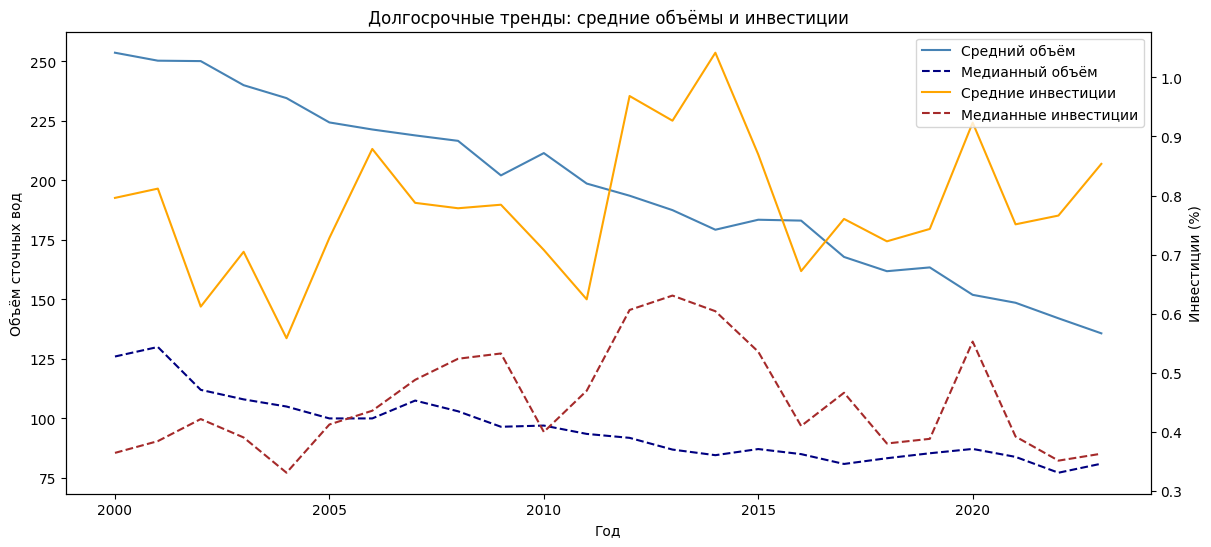

In [13]:
# 4. Долгосрочные тренды по годам
pivot = df.groupby('Год').agg({'Объем_сточных_вод_млн_м3':['mean', 'median'], 'Инвестиции_норм_%':['mean', 'median']})
pivot.columns = ['Объем_mean','Объем_median','Инв_mean','Инв_median']
pivot.reset_index(inplace=True)

fig, ax1 = plt.subplots(figsize=(14,6))
ax1.plot(pivot['Год'], pivot['Объем_mean'], label='Средний объём', color='steelblue')
ax1.plot(pivot['Год'], pivot['Объем_median'], label='Медианный объём', color='navy', linestyle='--')
ax2 = ax1.twinx()
ax2.plot(pivot['Год'], pivot['Инв_mean'], label='Средние инвестиции', color='orange')
ax2.plot(pivot['Год'], pivot['Инв_median'], label='Медианные инвестиции', color='brown', linestyle='--')
ax1.set_ylabel('Объём сточных вод')
ax2.set_ylabel('Инвестиции (%)')
ax1.set_xlabel('Год')
fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)
plt.title("Долгосрочные тренды: средние объёмы и инвестиции")
plt.show()

Сбросы сточныхх вод снижается — это позитивный тренд.

Расходы на экологию не растут — эффект снижения сбросов случается без существенного увеличения финансирования.

Связь между ростом инвестиций и снижением сбросов по всей стране не подтверждается по этим данным.

Положительный результат по экологии есть, но он не связан напрямую с изменениями инвестиций на федеральном уровне.

Снижение загрязнения произошло, но скорее из-за сторонних факторов (законы, технологии, закрытие старых заводов и т.п.)

C:\Users\go130\AppData\Local\Temp\ipykernel_19304\1513922167.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()  # Убираем легенду
C:\Users\go130\AppData\Local\Temp\ipykernel_19304\1513922167.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()  # Убираем легенду


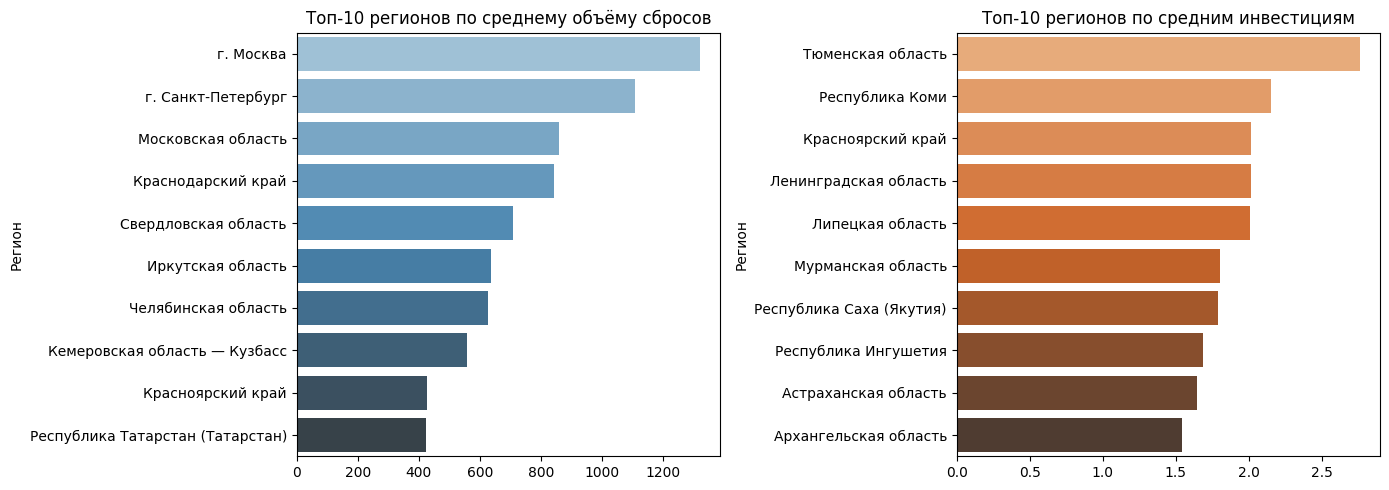

In [14]:
# 5. Топ-10 регионов по среднему объёму сбросов и инвестициям
top_vol = df.groupby('Регион')['Объем_сточных_вод_млн_м3'].mean().sort_values(ascending=False).head(10)
top_inv = df.groupby('Регион')['Инвестиции_норм_%'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.barplot(y=top_vol.index, x=top_vol.values, palette='Blues_d', hue=top_vol.index)
plt.title("Топ-10 регионов по среднему объёму сбросов")
plt.legend().remove()  # Убираем легенду

plt.subplot(1,2,2)
sns.barplot(y=top_inv.index, x=top_inv.values, palette='Oranges_d', hue=top_inv.index)
plt.title("Топ-10 регионов по средним инвестициям")
plt.legend().remove()  # Убираем легенду

plt.tight_layout()  
plt.show()